In [1]:
# Run from the repository root so data/, scripts/, dashboard/, outputs/ paths resolve.
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Descriptive Foundation
### `01_Descriptives.ipynb`

Descriptive groundwork for the situational-awareness (SA) study, providing the sample,
design, outcome and behavioural-predictor summaries that underpin the modelling notebooks
(`03_Accuracy_Detector`, `04_Latency_Detector`, `05_Confidence_Detector`, `06_GLMM_Analysis`).

Produces three publication tables (saved as CSV) and a descriptive figure panel:
- **Table 1**: participant characteristics (n = 37 operators).
- **Table 2**: SA-outcome descriptives, overall and by query type.
- **Table 3 (supplement Supplementary Table)**: pre-query (5 s window) behavioural-predictor descriptives.

Categorical/ordinal codings follow the project data dictionary (`4_Demo_PrePro.py`):
*Age* bands 1–6 (18–24 … 65+); *experience hours* bands 0–6 (weekly); years are continuous;
mental demand is a 0–100 (NASA-TLX-style) rating collected once per route.

**Packages & method.** pandas / numpy for the summaries and matplotlib for the figure panel; no modelling here, only descriptive statistics (counts, means, SDs, by-query-type breakdowns). The pre-query predictor table is the supplement's Supplementary Table.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD ALL QUERY EVENTS (all four query types, incl. Speed)
# ==========================================
# Descriptives characterise the WHOLE study, so we load the raw per-route ML files
# (Speed retained). The modelling notebooks subset these (e.g. accuracy purges Speed);
# participant-level demographics are identical to data/master_routes_1_to_6_combined.csv.
df = pd.concat([pd.read_csv(f"data/route{i}_ml_ready.csv").assign(Route=i) for i in range(1, 7)],
               ignore_index=True)
print(f"Loaded {len(df)} query events | {df['Participant_ID'].nunique()} operators "
      f"| {df['Route'].nunique()} routes")

# Dwell proportions (raw dwell / 5 s window), as in the modelling notebooks
for c in [c for c in df.columns if 'Before_Raw_Dwell' in c]:
    df[c.replace('Raw_Dwell', 'Dwell_Proportion')] = df[c] / 5.0

# === Road-gaze operationalisation and angular saccade units ===
# (1) MODELLING road-gaze proportion is the driver-monitoring "eyes-on-road" analog:
#     gaze on the forward driving feed, off only the physical off-screen references
#     (route map, name clipboard). The speed readout sat on-screen beside the road and
#     is retained as on-scene. The former measure (1 - dwell on ALL coded objects) is
#     kept as 'Diffuse_Gaze_Pct' for the descriptive query-type contrast only (it is
#     the near-complement of target dwell and carries no independent SA signal).
for _p in ['Before', 'During']:
    _off = [c for c in [f'{_p}_Raw_Dwell_map_Distractor', f'{_p}_Raw_Dwell_name_Distractor'] if c in df.columns]
    if f'{_p}_Road_Gaze_Pct' in df.columns and _off:
        _den = 5.0 if _p == 'Before' else df['Target_Latency'].clip(lower=1e-6)
        df[f'{_p}_Diffuse_Gaze_Pct'] = df[f'{_p}_Road_Gaze_Pct']
        df[f'{_p}_Road_Gaze_Pct'] = (1 - df[_off].sum(axis=1) / _den).clip(0, 1)
# (2) Saccadic amplitude/velocity to angular units. The Pupil Cloud export is linear in
#     visual angle (0.0746 deg/px; ~13.4 px/deg, SD 0.6%); a constant rescale leaves
#     tree-model and standardised-GLMM results identical and only changes reported units.
_DEG_PER_PX = 0.074562
for _p in ['Before', 'During']:
    for _b, _n in [(f'{_p}_Scanpath_Rate_px_s', f'{_p}_Scanpath_Rate_deg_s'),
                   (f'{_p}_Mean_Saccadic_Velocity', f'{_p}_Mean_Saccadic_Velocity_deg_s')]:
        if _b in df.columns:
            df[_n] = df[_b] * _DEG_PER_PX
df = df.copy()

# --- Data-dictionary label maps (for human-readable counts) ---
AGE_LABELS   = {1: '18-24', 2: '25-34', 3: '35-44', 4: '45-54', 5: '55+'}
HOURS_LABELS = {0: 'None', 1: '<1 h', 2: '1-3 h', 3: '4-6 h',
                4: '7-10 h', 5: '11-15 h', 6: '>15 h'}

def fmt_msd(s):       return f"{s.mean():.2f} ({s.std():.2f})"
def fmt_med_iqr(s):   return f"{s.median():.2f} [{s.quantile(.25):.2f}-{s.quantile(.75):.2f}]"

Loaded 659 query events | 37 operators | 6 routes


In [3]:
# ==========================================
# 2. SAMPLE & DESIGN DESCRIPTIVES
# ==========================================
print("="*64 + "\nSAMPLE & DESIGN\n" + "="*64)
n_part   = df['Participant_ID'].nunique()
n_events = len(df)
ev_per_p = df.groupby('Participant_ID').size()
print(f"Operators                 : {n_part}")
print(f"SA query events (total)   : {n_events}")
print(f"Events per operator       : median {ev_per_p.median():.0f} "
      f"(range {ev_per_p.min()}-{ev_per_p.max()})")
n_bad_lat = int((df['Target_Latency'] < 0).sum())
print(f"Invalid latency events    : {n_bad_lat}  (dropped from latency analyses -> "
      f"{n_events - n_bad_lat})")

print("\nQuery-type composition (fixed presentation order):")
qt = df['Question_Type'].value_counts()
for k, v in qt.items():
    print(f"   {k:8s} {v:3d}  ({v/n_events:.1%})")

SAMPLE & DESIGN
Operators                 : 37
SA query events (total)   : 659
Events per operator       : median 18 (range 14-18)
Invalid latency events    : 0  (dropped from latency analyses -> 659)

Query-type composition (fixed presentation order):
   Sign     221  (33.5%)
   Animal   218  (33.1%)
   Speed    147  (22.3%)
   Name      73  (11.1%)


In [4]:
# ==========================================
# 3. TABLE 1: PARTICIPANT CHARACTERISTICS (one row per operator)
# ==========================================
DEMO = ['Age_Num', 'Gender_Female', 'Gender_Male', 'Driving_Years_Num', 'Driving_Hours_Num',
        'Video_Game_Years_Num', 'Video_Game_Hours_Num', 'Experienced_Lag_Bin']
pp = df.groupby('Participant_ID')[DEMO].first()          # demographics are constant within operator
# Mental demand is collected once per route -> summarise each operator's mean across routes
pp['MentalDemand_mean'] = df.groupby('Participant_ID')['Subjective_Mental_Demand_Num'].mean()

rows = []
def add(label, value): rows.append({'Characteristic': label, 'Value': value})

add('Operators (n)', f"{len(pp)}")
add('Gender, Female : Male', f"{int(pp['Gender_Female'].sum())} : {int(pp['Gender_Male'].sum())}")
# Age bands (counts)
age_counts = pp['Age_Num'].map(AGE_LABELS).value_counts()
add('Age band, n', '; '.join(f"{AGE_LABELS[k]}: {int((pp['Age_Num']==k).sum())}"
                             for k in sorted(AGE_LABELS) if (pp['Age_Num']==k).any()))
add('Driving experience, years M (SD)', fmt_msd(pp['Driving_Years_Num']))
add('Weekly driving, modal band', f"{HOURS_LABELS[int(pp['Driving_Hours_Num'].mode()[0])]} "
    f"(median band {HOURS_LABELS[int(pp['Driving_Hours_Num'].median())]})")
add('Gaming experience, years M (SD)', fmt_msd(pp['Video_Game_Years_Num']))
non_gamers = int((pp['Video_Game_Hours_Num'] == 0).sum())
add('Non-gamers (0 weekly h), n', f"{non_gamers} / {len(pp)}")
add('Weekly gaming, modal band', f"{HOURS_LABELS[int(pp['Video_Game_Hours_Num'].mode()[0])]}")
add('Prior teleoperation-lag experience, n (Yes)', f"{int(pp['Experienced_Lag_Bin'].sum())} / {len(pp)}")
add('Subjective mental demand (0-100), M (SD)', fmt_msd(pp['MentalDemand_mean']))

table1 = pd.DataFrame(rows)
print("="*64 + "\nTABLE 1. PARTICIPANT CHARACTERISTICS\n" + "="*64)
print(table1.to_string(index=False))
table1.to_csv("outputs/Table1_Demographics.csv", index=False)
print("\nSaved -> outputs/Table1_Demographics.csv")

TABLE 1. PARTICIPANT CHARACTERISTICS
                             Characteristic                                                    Value
                              Operators (n)                                                       37
                      Gender, Female : Male                                                  16 : 21
                                Age band, n 18-24: 9; 25-34: 7; 35-44: 8; 45-54: 6; 55-64: 6; 65+: 1
           Driving experience, years M (SD)                                            18.14 (14.42)
                 Weekly driving, modal band                               7-10 h (median band 4-6 h)
            Gaming experience, years M (SD)                                             8.03 (11.06)
                 Non-gamers (0 weekly h), n                                                  19 / 37
                  Weekly gaming, modal band                                                     None
Prior teleoperation-lag experience, n (Yes)           

In [5]:
# ==========================================
# 4. TABLE 2: SA-OUTCOME DESCRIPTIVES (overall + by query type)
# ==========================================
FREEZE_S = 3.5
d = df.copy()
d['incorrect'] = (1 - d['Target_Accuracy']).astype(int)
d_lat = d[d['Target_Latency'] >= 0].copy()              # drop invalid sentinel for latency
d_lat['freeze'] = (d_lat['Target_Latency'] >= FREEZE_S).astype(int)

def outcome_block(sub_all, sub_lat, label):
    return {
        'Group': label,
        'n (events)': len(sub_all),
        'Incorrect %': f"{sub_all['incorrect'].mean():.1%}",
        'Latency M (SD) s': f"{sub_lat['Target_Latency'].mean():.2f} ({sub_lat['Target_Latency'].std():.2f})",
        'Latency median [IQR] s': fmt_med_iqr(sub_lat['Target_Latency']),
        'Freeze >=3.5s %': f"{sub_lat['freeze'].mean():.1%}",
        'Confidence M (SD)': f"{sub_all['Target_Confidence'].mean():.2f} ({sub_all['Target_Confidence'].std():.2f})",
    }

t2 = [outcome_block(d, d_lat, 'ALL queries')]
for qt in ['Sign', 'Animal', 'Name', 'Speed']:
    if (d['Question_Type'] == qt).any():
        t2.append(outcome_block(d[d['Question_Type'] == qt],
                                d_lat[d_lat['Question_Type'] == qt], qt))
table2 = pd.DataFrame(t2)
print("="*92 + "\nTABLE 2. SA-OUTCOME DESCRIPTIVES (overall and by query type)\n" + "="*92)
print(table2.to_string(index=False))
table2.to_csv("outputs/Table2_Outcomes.csv", index=False)

# Confidence distribution (ceiling skew) + correctness base rate
print("\nConfidence (1-7) distribution:",
      dict(d['Target_Confidence'].value_counts().sort_index().astype(int)))
print(f"   ceiling-skewed: {(d['Target_Confidence']>=6).mean():.0%} answered >= 6")
print(f"Overall accuracy: {d['Target_Accuracy'].mean():.1%} correct "
      f"({int(d['incorrect'].sum())} incorrect)")
print("\nSaved -> outputs/Table2_Outcomes.csv")

TABLE 2. SA-OUTCOME DESCRIPTIVES (overall and by query type)
      Group  n (events) Incorrect % Latency M (SD) s Latency median [IQR] s Freeze >=3.5s % Confidence M (SD)
ALL queries         659       15.8%      2.14 (1.24)       1.73 [1.36-2.53]           10.8%       5.52 (1.87)
       Sign         221       22.6%      2.29 (1.31)       1.85 [1.37-2.70]           13.6%       5.19 (2.17)
     Animal         218       20.6%      2.31 (1.40)       1.96 [1.37-2.96]           13.8%       5.23 (1.77)
       Name          73        9.6%      2.03 (0.92)       1.77 [1.40-2.41]            8.2%       5.88 (1.59)
      Speed         147        1.4%      1.74 (0.89)       1.55 [1.35-1.76]            3.4%       6.24 (1.38)

Confidence (1-7) distribution: {1.0: 48, 2.0: 25, 3.0: 27, 4.0: 58, 5.0: 81, 6.0: 121, 7.0: 299}
   ceiling-skewed: 64% answered >= 6
Overall accuracy: 84.2% correct (104 incorrect)

Saved -> outputs/Table2_Outcomes.csv


In [6]:
# ==========================================
# 5. TABLE 3: PRE-QUERY BEHAVIOURAL PREDICTOR DESCRIPTIVES (5 s 'Before' window)
# ==========================================
# The candidate predictors used across the modelling notebooks, with readable labels.
PREDICTORS = {
    'Before_Dwell_Proportion_Target_Object': 'Target-object dwell (prop.)',
    'Before_Road_Gaze_Pct'                 : 'Road-gaze (prop.)',
    'Before_Saccade_Rate_Hz'               : 'Saccade rate (Hz)',
    'Before_Mean_Saccadic_Velocity_deg_s'  : 'Mean saccadic velocity (deg/s)',
    'Before_Scanpath_Rate_deg_s'           : 'Scanpath rate (deg/s)',
    'Before_Speed_Variance'                : 'Speed variance',
    'Before_Steer_Variance'                : 'Steering variance',
    'Before_Mean_Abs_Steering'             : 'Mean absolute steering',
    'Before_Major_SRR'                     : 'Major steering-reversal rate',
    'Before_Fine_SRR'                      : 'Fine steering-reversal rate',
    'Before_TRR'                           : 'Throttle-reversal rate',
    'Before_Zero_Throttle_Pct'             : 'Zero-throttle (%)',
    'Before_Mean_Speed_mph'                : 'Mean speed (mph)',
}
# NB: brake (Before_Max_Brake / Before_Mean_Brake) is identically 0 in every pre-query
# window, operators did not brake in the 5 s before a query, so it is a zero-variance,
# non-informative predictor and is omitted from the table (noted in the caveats below).
# Reported over the Sign + Animal modelling sample (n = 439): the events the
# detectors are actually fit on, so the pooled means (esp. target-object dwell)
# reflect the modelled predictors rather than being diluted by the off-scene
# Name / Speed events (which have no in-scene target to dwell on). The whole-study
# behaviour is still on record via the SA-outcomes table and Table S3 below.
df_model = df[df['Question_Type'].isin(['Sign', 'Animal'])]
rows = []
for col, lab in PREDICTORS.items():
    if col in df_model.columns:
        s = df_model[col]
        rows.append({'Predictor': lab, 'M': s.mean(), 'SD': s.std(),
                     'Median': s.median(), 'Min': s.min(), 'Max': s.max()})
table3 = pd.DataFrame(rows)
print("="*84 + "\nTABLE 3. PRE-QUERY (5 s) BEHAVIOURAL PREDICTOR DESCRIPTIVES (Sign + Animal, n = 439)\n" + "="*84)
print(table3.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
table3.to_csv("outputs/Table3_Predictors.csv", index=False)
print("\nSaved -> outputs/Table3_Predictors.csv")

# ==========================================
# 5b. TABLE S3: TARGET-OBJECT DWELL BY QUERY TYPE
# ==========================================
# The pooled target-dwell row above is zero-inflated (median 0) because the Name
# target is an off-scene route-map reference and Speed a brief speedometer glance,
# so neither has an in-scene object to dwell on before the query. Broken out by
# query type the measure is non-degenerate on Sign and Animal (where it is a
# predictor). %zero reported because the zeros carry the situational-awareness
# meaning (no anticipatory fixation of the to-be-queried object).
TGT = 'Before_Dwell_Proportion_Target_Object'
def _dwell_stats(s):
    return {'n': len(s), 'M': s.mean(), 'SD': s.std(), 'Median': s.median(),
            'Min': s.min(), 'Max': s.max(), '%zero': 100 * (s == 0).mean()}
brk = []
for qt in ['Sign', 'Animal', 'Name', 'Speed']:
    brk.append({'Query type': qt, **_dwell_stats(df.loc[df['Question_Type'] == qt, TGT])})
brk.append({'Query type': 'Sign + Animal',
            **_dwell_stats(df.loc[df['Question_Type'].isin(['Sign', 'Animal']), TGT])})
brk.append({'Query type': 'All pooled', **_dwell_stats(df[TGT])})
table_s3 = pd.DataFrame(brk)
print("\n" + "=" * 84 + "\nTABLE S3. PRE-QUERY TARGET-OBJECT DWELL BY QUERY TYPE\n" + "=" * 84)
print(table_s3.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
table_s3.to_csv("outputs/TableS3_TargetDwell_ByType.csv", index=False)
print("\nSaved -> outputs/TableS3_TargetDwell_ByType.csv")

TABLE 3. PRE-QUERY (5 s) BEHAVIOURAL PREDICTOR DESCRIPTIVES (Sign + Animal, n = 439)
                     Predictor       M     SD  Median   Min     Max
   Target-object dwell (prop.)   0.063  0.103   0.008 0.000   0.664
             Road-gaze (prop.)   0.958  0.071   1.000 0.366   1.000
             Saccade rate (Hz)   1.810  0.648   1.800 0.000   4.200
Mean saccadic velocity (deg/s) 188.905 41.827 187.447 0.000 303.392
         Scanpath rate (deg/s)  16.426  9.323  15.350 0.000  45.284
                Speed variance   0.306  0.364   0.166 0.000   2.435
             Steering variance   0.054  0.091   0.022 0.000   0.831
        Mean absolute steering   0.669  0.323   0.793 0.016   1.000
  Major steering-reversal rate   0.139  0.126   0.200 0.000   0.600
   Fine steering-reversal rate   0.248  0.173   0.200 0.000   0.600
        Throttle-reversal rate   0.175  0.202   0.000 0.000   0.800
             Zero-throttle (%)  14.364 19.758   3.500 0.000 100.000
              Mean speed (mph) 

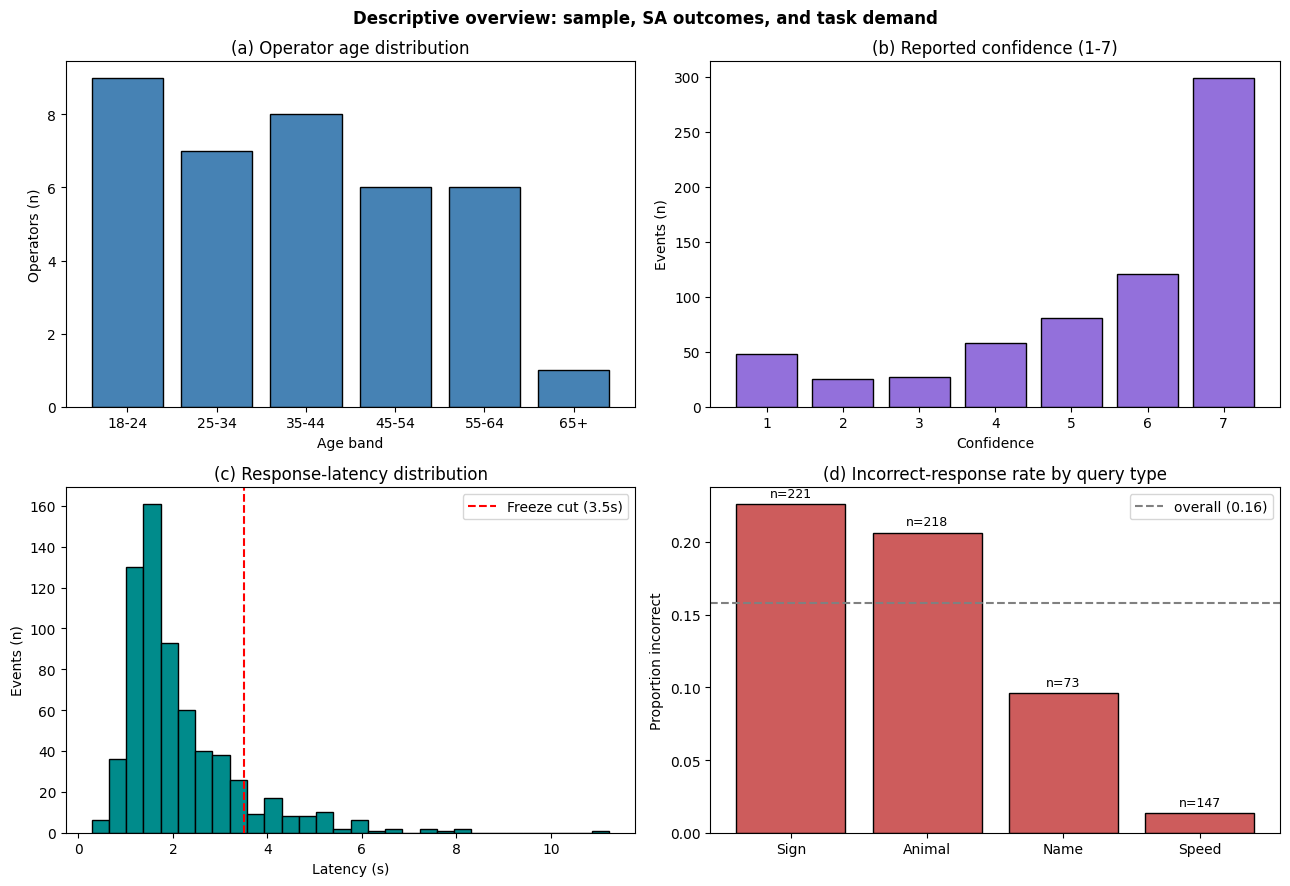

Saved -> outputs/Descriptives_Panel.png


In [7]:
# ==========================================
# 6. DESCRIPTIVE FIGURE PANEL
# ==========================================
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (a) Age-band distribution
order = [k for k in sorted(AGE_LABELS) if (pp['Age_Num'] == k).any()]
ax[0, 0].bar([AGE_LABELS[k] for k in order], [int((pp['Age_Num'] == k).sum()) for k in order],
             color='steelblue', edgecolor='black')
ax[0, 0].set_title('(a) Operator age distribution'); ax[0, 0].set_ylabel('Operators (n)')
ax[0, 0].set_xlabel('Age band')

# (b) Confidence distribution (ceiling skew)
cc = d['Target_Confidence'].value_counts().sort_index()
ax[0, 1].bar(cc.index, cc.values, color='mediumpurple', edgecolor='black')
ax[0, 1].set_title('(b) Reported confidence (1-7)'); ax[0, 1].set_xlabel('Confidence')
ax[0, 1].set_ylabel('Events (n)')

# (c) Latency distribution + freeze cut
ax[1, 0].hist(d_lat['Target_Latency'], bins=30, color='darkcyan', edgecolor='black')
ax[1, 0].axvline(FREEZE_S, color='red', ls='--', label=f'Freeze cut ({FREEZE_S}s)')
ax[1, 0].set_title('(c) Response-latency distribution'); ax[1, 0].set_xlabel('Latency (s)')
ax[1, 0].set_ylabel('Events (n)'); ax[1, 0].legend()

# (d) Incorrect-response rate by query type (with n labels)
qts = [q for q in ['Sign', 'Animal', 'Name', 'Speed'] if (d['Question_Type'] == q).any()]
inc = [d.loc[d['Question_Type'] == q, 'incorrect'].mean() for q in qts]
ns  = [int((d['Question_Type'] == q).sum()) for q in qts]
bars = ax[1, 1].bar(qts, inc, color='indianred', edgecolor='black')
ax[1, 1].axhline(d['incorrect'].mean(), color='gray', ls='--',
                 label=f"overall ({d['incorrect'].mean():.2f})")
for b, n in zip(bars, ns):
    ax[1, 1].text(b.get_x() + b.get_width()/2, b.get_height() + .005, f"n={n}",
                  ha='center', fontsize=9)
ax[1, 1].set_title('(d) Incorrect-response rate by query type')
ax[1, 1].set_ylabel('Proportion incorrect'); ax[1, 1].legend()

fig.suptitle('Descriptive overview: sample, SA outcomes, and task demand', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/Descriptives_Panel.png', dpi=130); plt.show(); plt.close()
print("Saved -> outputs/Descriptives_Panel.png")

### Notes / caveats for reporting
- **Age** and **weekly-experience hours** are ordinal bands (data dictionary in
  `4_Demo_PrePro.py`); years of driving/gaming are continuous. Report age as band counts,
  not a mean of the codes.
- **Mental demand** (NASA-TLX-style, 0–100) is collected **once per route**, so the Table 1
  entry is each operator's mean across the six routes; it can also be analysed at the
  route level.
- **Query types are unbalanced and were presented in fixed order** (Sign/Animal dominate;
  Name and Speed are sparser). Speed queries are near-ceiling for accuracy (~1% incorrect)
  and are purged from the accuracy model; latency drops one invalid (negative) event.
- These descriptives use **all** query events; the modelling notebooks apply their own
  outcome-specific subsetting.
- **Braking was effectively absent** in the pre-query window (`Before_Max_Brake` and
  `Before_Mean_Brake` are identically 0 across all events), so brake features carry no
  variance and are excluded from Table 3 and from interpretation.